In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

In [4]:
PLOT_FOLDER = Path('../plots')
RESULT_FOLDER = Path('../results')
# colors = 
N_CLUSTER_LIST = list(range(2, 7))
RED, YELLOW, BLUE = '#c00000', '#dcd844', '#0033cc'

PLOT_PARAMS = dict(bbox_inches='tight', transparent=True, dpi=600)

# Validity

In [61]:
def plot(data):
    # key, label, direction, marker, color, darkened_color
    # y_lim, y_ticks, ax_cut_pos
    params = [('silhouette_score', 'Silhouette Coefficient', '^', '#9B59B6', '#6c3f7f', (0, 0)),
              ('davies_bouldin_score', 'Davies Bouldin Index', 'o', '#1ABC9C', '#128973', (1, 1),), ]

    fig, ax1 = plt.subplots(figsize=(5, 2.5))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]

    # plot scores: lines and points
    x, d = N_CLUSTER_LIST, 0.5
    for i, ax in enumerate(axes):
        (key, label, marker, color, darkened_color, ax_cut_pos) = params[i]

        sns.pointplot(data=data, x='n_clusters', y=key, color=color, ax=ax)

        # set up axis
        ax.set_ylabel(label, color=darkened_color, fontsize=10)
        ax.tick_params(axis='y', colors=darkened_color)
        ax.set_xlabel('')

        # add cut in axis
        kwargs = dict(markersize=12, linestyle="none", color=darkened_color, mec=color, mew=1, clip_on=False)
        ax.plot(ax_cut_pos, [0.02, 0.05], marker=[(-1, d), (1, -d)], transform=ax2.transAxes, **kwargs)

    # plot settings
    ax2.spines['left'].set_color(params[0][-2])
    ax2.spines['left'].set_linewidth(2)
    ax1.tick_params(axis='y', width=2)

    ax2.spines['right'].set_color(params[1][-2])
    ax2.spines['right'].set_linewidth(2)
    ax2.tick_params(axis='y', width=2)

    ax2.spines['bottom'].set_color('black')

    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    ax1.spines['bottom'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.set_xlim(-0.8, 4.8)
    return fig


def plot_bar(data):

    # key, label, direction, marker, color, darkened_color
    # y_lim, y_ticks, ax_cut_pos
    params = [('silhouette_score', 'Silhouette Coefficient', '^', '#9B59B6', '#6c3f7f', (0, 0)),
              ('davies_bouldin_score', 'Davies Bouldin Index', 'o', '#1ABC9C', '#128973', (1, 1),), ]

    fig, ax1 = plt.subplots(figsize=(5, 2.5))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]

    # plot scores: lines and points
    x, d = N_CLUSTER_LIST, 0.5
    for i, ax in enumerate(axes):
        (key, label, marker, color, darkened_color, ax_cut_pos) = params[i]

        sns.lineplot(data=data, x=data['n_clusters'].astype(int) + i * 0.2 - 0.1, y=key, color=color, ax=ax, errorbar=None, estimator='median',
                     linestyle='--', alpha=0.4      )
        sns.boxplot(data=data, x=data['n_clusters'].astype(int) + i * 0.2 - 0.1, y=key, color=color, ax=ax, width=0.15,
                    native_scale=True, fliersize=0)

        # set up axis
        ax.set_ylabel(label, color=darkened_color, fontsize=10)
        ax.tick_params(axis='y', colors=darkened_color)
        ax.set_xlabel('')

        # add cut in axis
        kwargs = dict(markersize=12, linestyle="none", color=darkened_color, mec=color, mew=1, clip_on=False)
        ax.plot(ax_cut_pos, [0.02, 0.05], marker=[(-1, d), (1, -d)], transform=ax2.transAxes, **kwargs)

    # plot settings
    ax2.spines['left'].set_color(params[0][-2])
    ax2.spines['left'].set_linewidth(2)
    ax1.tick_params(axis='y', width=2)

    ax2.spines['right'].set_color(params[1][-2])
    ax2.spines['right'].set_linewidth(2)
    ax2.tick_params(axis='y', width=2)

    ax2.spines['bottom'].set_color('black')

    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    ax1.spines['bottom'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    # ax2.set_xlim(0.8, 6.8)
    return fig


../results/internal_validity/BCP_age_0_3_resting.tsv
../results/internal_validity/dHCP_PCW_20_45_resting.tsv
../results/internal_validity/HCP_A_age_36_60_resting.tsv
../results/internal_validity/HCP_A_age_61_100_resting.tsv
../results/internal_validity/HCP_D_age_05_11_resting.tsv
../results/internal_validity/HCP_D_age_12_21_resting.tsv
../results/internal_validity/HCP_YA_age_22_35_DTI.tsv
../results/internal_validity/HCP_YA_age_22_35_movie.tsv
../results/internal_validity/HCP_YA_age_22_35_resting.tsv
../results/internal_validity/HCP_YA_age_22_35_resting_3T.tsv
../results/internal_validity/HCP_YA_age_22_35_resting_7T.tsv
../results/internal_validity/Inhouse_age_18_30_DTI.tsv
../results/internal_validity/Inhouse_age_18_30_resting.tsv
../results/internal_validity/Primate.tsv


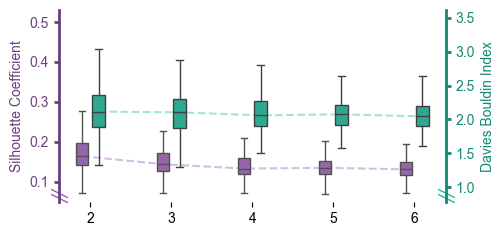

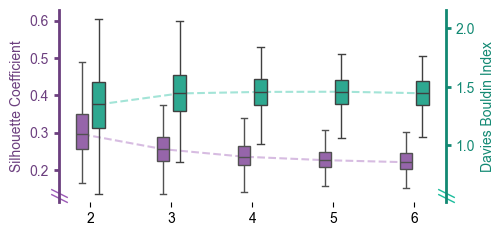

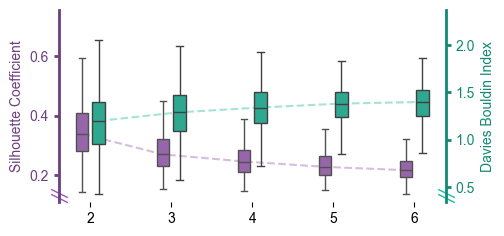

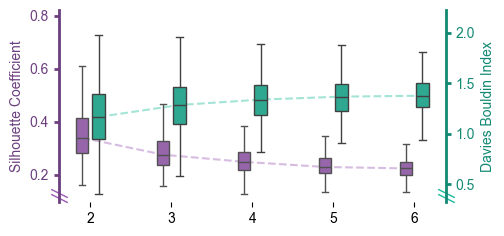

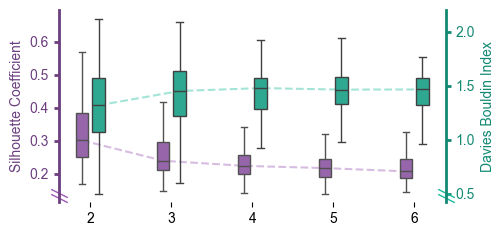

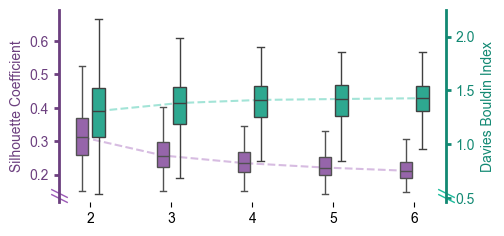

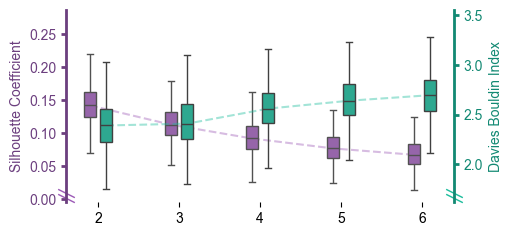

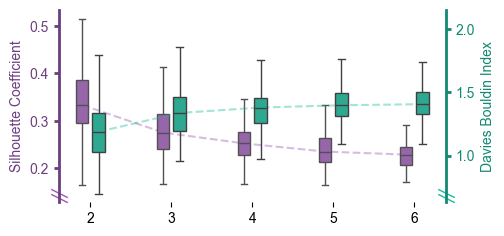

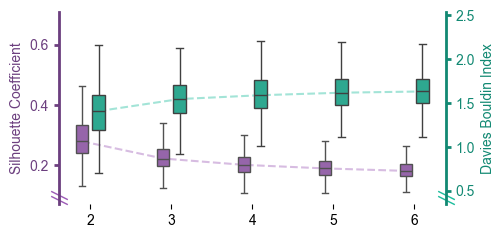

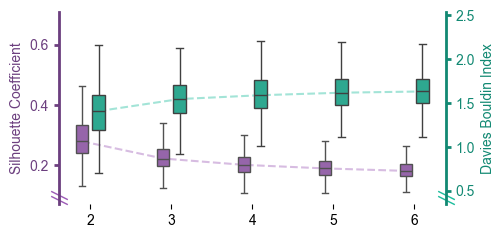

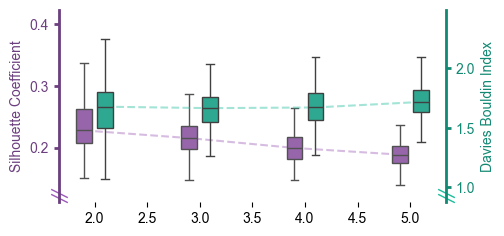

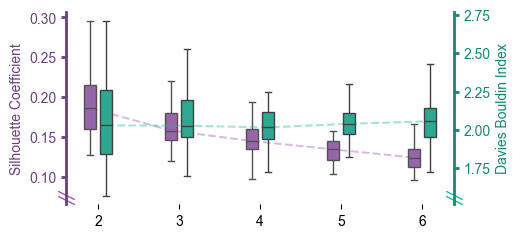

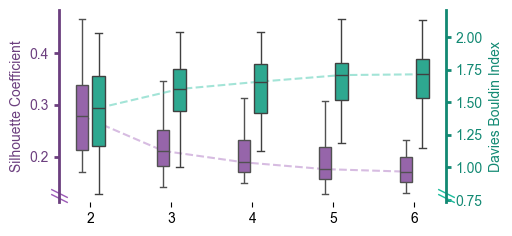

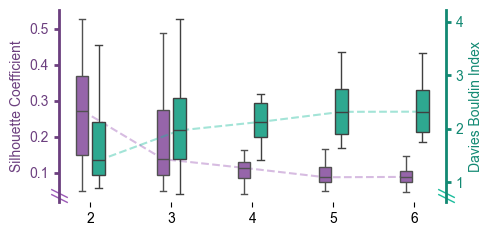

In [64]:
data_folder = RESULT_FOLDER / 'internal_validity'
for file in data_folder.iterdir():
    data = pd.read_csv(file, sep='\t')
    print(file)

    fig = plot(data)
    fig.savefig(PLOT_FOLDER / f'internal_validity/{file.stem}.svg', **PLOT_PARAMS)
    fig.savefig(PLOT_FOLDER / f'internal_validity/{file.stem}.png', **PLOT_PARAMS)

In [5]:
data_folder = RESULT_FOLDER / 'internal_validity'
for file in data_folder.iterdir():
    data = pd.read_csv(file, sep='\t')

    if file.stem == 'HCP_YA_age_22_35_7Tresting':
        df_list = []
        for participant_id, df in data.groupby(['participant_id']):
            new_row = df.iloc[-1] + df.diff().iloc[-1]
            df = pd.concat([df, new_row.to_frame().T], axis=0)
            df_list.append(df)

        data = pd.concat(df_list)

